# 10 · Blackboards: shared observations

## Learning objectives

- Register read and write access.
- Inspect state and activity.
- Keep observations separate from decisions.

**Environment:** the standalone Python kernel from the README. No ROS installation or sourcing is needed. Run all cells from top to bottom; each notebook starts with its own state.

## Intuition

A **blackboard** is named shared memory. A sensor-like component writes an observation;
a decision reads it. Clients document which keys they use. Access registration catches
accidental misuse, but is not a security boundary or a thread-safety mechanism. py_trees
blackboards are process-local: they do not magically share data between ROS nodes.

In [2]:
import py_trees as pt
from behavior_trees_tutorial.behaviors.common import Function, CountTicks, Status
from behavior_trees_tutorial.visualization import diagram, trace, playground
from IPython.display import display

## Minimal working example

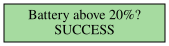

In [3]:
from uuid import uuid4
namespace = "/lesson10_" + uuid4().hex
writer = pt.blackboard.Client(name="Observer", namespace=namespace)
reader = pt.blackboard.Client(name="Decision", namespace=namespace)
writer.register_key("battery", access=pt.common.Access.WRITE)
reader.register_key("battery", access=pt.common.Access.READ)
writer.battery = 0.8
root = Function("Battery above 20%?", lambda: Status.SUCCESS if reader.battery > 0.2 else Status.FAILURE)
root.tick_once()
assert root.status is Status.SUCCESS
display(diagram(root))

## Step-by-step implementation
Initialize a key before reading it. Use a namespace to keep examples independent on rerun.
Activity logging is useful for debugging but is global to this process. A real observation
should often include a timestamp: a plausible but stale value can be more dangerous than
an explicitly missing value.

In [4]:
pt.blackboard.Blackboard.enable_activity_stream(maximum_size=20)
writer.battery = 0.1
root.tick_once()
print("Battery:", reader.battery, "Decision:", root.status.name)
print(pt.display.unicode_blackboard_activity_stream())
assert root.status is Status.FAILURE
pt.blackboard.Blackboard.disable_activity_stream()

Battery: 0.1 Decision: FAILURE
Blackboard Activity Stream
    /lesson10_8b8ee9c45c9e4e14ba7afa34e22792e8/battery : WRITE         | Observer | → ...
    /lesson10_8b8ee9c45c9e4e14ba7afa34e22792e8/battery : READ          | Decision | ← ...
    /lesson10_8b8ee9c45c9e4e14ba7afa34e22792e8/battery : READ          | Decision | ← ...


## Interactive demonstration
The slider writes the observation; the leaf reads it. This is an explicit data path.

In [5]:
import ipywidgets as widgets

@widgets.interact(charge=(0.0, 1.0, 0.1))
def inspect_battery(charge=0.8):
    writer.battery = charge
    root.tick_once()
    print("Blackboard battery =", reader.battery)
    display(diagram(root))

interactive(children=(FloatSlider(value=0.8, description='charge', max=1.0), Output()), _dom_classes=('widget-…

## Key observations

Use the blackboard for observations and task state, not as a hidden substitute for clear interfaces. Namespace keys and assign writers deliberately.

## Exercises

1. Add a last_seen timestamp and reject stale readings.
2. Read an uninitialized key and explain the error.

Hints and worked solutions: `exercises/README.md` and `solutions/README.md` (lesson 10).

## Summary

Shared observations make changing conditions visible to the tree. Next we use them to interrupt lower-priority work.